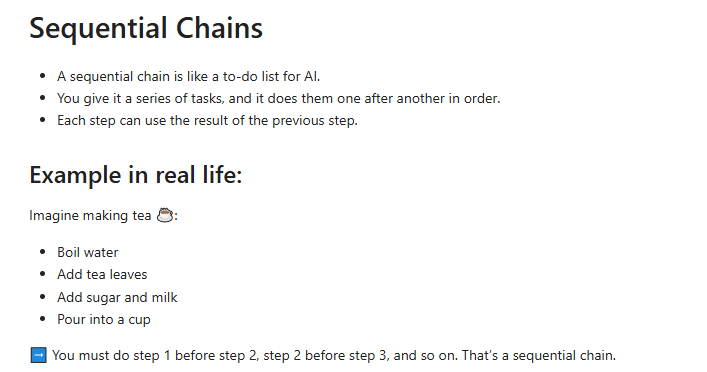

In [ ]:
!pip install langchain-google-genai

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain.schema.output_parser import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnableSequence
from google.colab import userdata

In [3]:
#getting api key
api_key = userdata.get("GOOGLE_API_KEY")

In [6]:
#selecting the model
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.0-flash",
    google_api_key = api_key
)

In [7]:
#providing 2 templates
Template1 = [
    ("system", "You are a facts expert who knows facts about {animal}."),
    ("human", "Tell me {count} facts.")
]
Template2 = [
     ("system", "You are a translator and convert the provided text into {language}."),
     ("human", "Translate the following text to {language}: {text}"),
]

#converting the template1 into chat prompt
animal_template = ChatPromptTemplate.from_messages(Template1)

#Converting the template2 into chat prompt
language_template = ChatPromptTemplate.from_messages(Template2)

In [15]:
# This takes the text (called output) and wraps it inside a dictionary with two parts:
# "text" → the actual text you want to translate
# "language" → the target language (here "Urdu")
translation = RunnableLambda(lambda output: {"text":output, "language":"urdu"})

In [16]:
#make a chain
chain = animal_template | llm | StrOutputParser() | translation | language_template | llm | StrOutputParser()

#filling the chain with actual values
response = chain.invoke({
    "animal":"cat", "count":3
})

#getting response
print(response)

ٹھیک ہے، یہاں بلیوں کے بارے میں 3 حقائق ہیں:

1.  **بلیوں کی تیسری پلک ہوتی ہے:** جسے نیکٹیٹیٹنگ ممبرین (nictitating membrane) کہتے ہیں، یہ پلک آنکھ کو اضافی تحفظ اور نمی فراہم کرتی ہے۔ آپ اسے ان کی آنکھ پر جھپکتے ہوئے دیکھ سکتے ہیں اگر وہ سو رہے ہوں یا طبیعت ٹھیک نہ ہو۔
2.  **بلی کی ناک کا نشان منفرد ہوتا ہے، جیسے انسانی فنگر پرنٹ:** بلی کی ناک پر موجود ابھار اور لکیروں کا نمونہ ہر بلی کے لیے مخصوص ہوتا ہے۔
3.  **بلیاں 100 سے زیادہ مختلف آوازیں نکال سکتی ہیں:** اس کے برعکس، کتے صرف تقریباً 10 آوازیں نکال سکتے ہیں!
